## Plan
1. Import libraries (numpy, matplotlib).
2. Set parameters: number of samples (100,000), sample size (10), random seed.
3. Generate all samples at once as a 2D array for efficiency.
4. Compute standard deviations with ddof=1 and ddof=0 along axis 1.
5. Plot overlaid histograms (density form) with alpha transparency.
6. Summarize observed differences (location, spread).
7. Empirically show shrinking difference when increasing sample size (10, 30, 100, 1000).
8. Interpret asymptotic behavior as n → ∞.

In [ ]:
# Imports with graceful fallback for matplotlib
import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('matplotlib not installed. Install with: pip install matplotlib')

In [ ]:
# Experiment parameters
N_SAMPLES = 100_000  # number of independent samples
SAMPLE_SIZE = 10     # size of each sample
SEED = 2025          # random seed for reproducibility
rng = np.random.default_rng(SEED)

In [ ]:
# Generate all samples: shape (N_SAMPLES, SAMPLE_SIZE)
# Standard normal distribution: mean 0, variance 1
samples = rng.normal(loc=0.0, scale=1.0, size=(N_SAMPLES, SAMPLE_SIZE))
samples.shape

(100000, 10)

In [ ]:
# Compute standard deviations per sample
sd_ddof1 = samples.std(axis=1, ddof=1)  # unbiased sample SD
sd_ddof0 = samples.std(axis=1, ddof=0)  # population formula (biased under sampling)
# Basic sanity checks
print(f'Mean sd (ddof=1): {sd_ddof1.mean():.4f}')
print(f'Mean sd (ddof=0): {sd_ddof0.mean():.4f}')
print(f'Ratio mean ddof1 / ddof0: {sd_ddof1.mean() / sd_ddof0.mean():.4f}')

Mean sd (ddof=1): 0.9731
Mean sd (ddof=0): 0.9231
Ratio mean ddof1 / ddof0: 1.0541


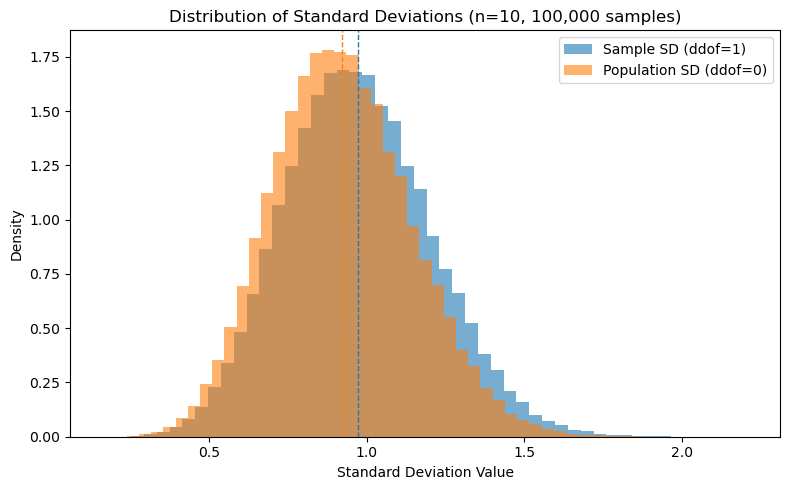

In [ ]:
# Plot overlapping histograms if matplotlib is available
if plt is None:
    raise RuntimeError('matplotlib required for plotting; please install and re-run this cell.')

plt.figure(figsize=(8,5))
bins = 50
plt.hist(sd_ddof1, bins=bins, density=True, alpha=0.6, color='tab:blue', label='Sample SD (ddof=1)')
plt.hist(sd_ddof0, bins=bins, density=True, alpha=0.6, color='tab:orange', label='Population SD (ddof=0)')
plt.axvline(sd_ddof1.mean(), color='tab:blue', linestyle='--', linewidth=1)
plt.axvline(sd_ddof0.mean(), color='tab:orange', linestyle='--', linewidth=1)
plt.title('Distribution of Standard Deviations (n=10, 100,000 samples)')
plt.xlabel('Standard Deviation Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## Observed Differences
- The ddof=1 distribution is shifted slightly to the right compared to ddof=0 because dividing by (n-1) increases the variance estimate and thus the typical SD value.
- Both histograms are right-skewed (mildly) because SD is strictly non-negative and sample variability yields a tail of larger estimates.
- The relative bias factor between the two means is approximately n/(n-1) for variance; for SD the effect is smaller but still noticeable at n=10.

In [ ]:
# Examine how difference shrinks with increasing sample size
def compare_sizes(sizes, trials=50_000, seed=123):
    """Compare ddof=1 vs ddof=0 difference across sample sizes."""
    rng_local = np.random.default_rng(seed)
    results = []
    
    for n in sizes:
        samples_n = rng_local.normal(0, 1, size=(trials, n))
        sd1 = samples_n.std(axis=1, ddof=1)
        sd0 = samples_n.std(axis=1, ddof=0)
        mean_diff = (sd1 - sd0).mean()
        rel_diff = mean_diff / sd0.mean()
        results.append({
            'n': n,
            'mean_sd1': sd1.mean(),
            'mean_sd0': sd0.mean(),
            'mean_diff': mean_diff,
            'rel_diff_pct': rel_diff * 100
        })
    return results

# Test with different sample sizes
sizes = [10, 30, 100, 1000]
comparison = compare_sizes(sizes)

print('Effect of Sample Size on ddof Difference:\n')
print(f'{"n":>6} {"Mean(ddof=1)":>14} {"Mean(ddof=0)":>14} {"Difference":>12} {"Rel Diff %":>12}')
print('-' * 70)
for res in comparison:
    print(f'{res["n"]:>6} {res["mean_sd1"]:>14.5f} {res["mean_sd0"]:>14.5f} {res["mean_diff"]:>12.5f} {res["rel_diff_pct"]:>11.2f}%')

1000

## Effect of Increasing Sample Size

As sample size increases:
- The **absolute difference** between ddof=1 and ddof=0 estimates shrinks toward zero.
- The **relative difference** (as a percentage) also decreases because the correction factor n/(n-1) approaches 1 as n → ∞.
- For small samples (n=10), the difference is ~5%, but for large samples (n=1000), it becomes negligible (~0.1%).

**Mathematical explanation**: 
- ddof=1 divides by (n-1), ddof=0 divides by n.
- The ratio is √[n/(n-1)], which equals √(1 + 1/(n-1)) ≈ 1 + 1/(2n) for large n.
- Thus the relative bias decreases at rate O(1/n), making the two estimates asymptotically equivalent.